# NLTK Basics - Practical Notebook

This notebook introduces the fundamentals of Natural Language Processing (NLP) using the NLTK library.

We explore how raw text can be transformed into structured and meaningful information through key NLP techniques:

- Tokenization (sentence and word splitting)
- Stopwords removal and text cleaning
- N-grams and Collocations for phrase detection
- Part-of-Speech (POS) tagging for grammatical structure
- Named Entity Recognition (NER) for extracting real-world entities
- WordNet for exploring synonyms, antonyms, and semantic relationships
- Lemmatization with POS for accurate word normalization
- Text similarity using Jaccard distance
- TF-IDF for converting text into machine learning features

The goal of this notebook is to build intuition for classical NLP pipelines and understand how text data is processed before applying machine learning models.

## Installation & Setup

In [3]:
# If not installed
#!pip install nltk

In [27]:
import nltk

# Download essential datasets (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Sample Text

In [10]:
text = """
Natural Language Processing (NLP) is a fascinating field of Artificial Intelligence.
It allows computers to understand, interpret, and generate human language.
NLTK is a leading platform for building Python programs to work with human language data.
"""
print(text)


Natural Language Processing (NLP) is a fascinating field of Artificial Intelligence.
It allows computers to understand, interpret, and generate human language.
NLTK is a leading platform for building Python programs to work with human language data.



In [73]:
long_text = """
"The rapid advancement of artificial intelligence (AI) has significantly transformed the landscape of modern technology in the 2020s. Natural Language Processing (NLP), a critical subfield of AI, allows computers to understand, interpret, and generate human language. For instance, on 2026-05-03, a new deep learning model was released to analyze complex text patterns, achieving a 95% accuracy rate in sentiment analysis tasks, which is quite impressive!However, the field is not without challenges. Data pre-processing—which includes tokenization, stop word removal, and lemmatization—is essential but time-consuming. For example, when processing data for platforms like Twitter or Reddit, one must handle unstructured, chaotic text, including misspelled words ("luv" for "love") and excessive punctuation (!!!). Furthermore, machine translation, a common NLP application, often struggles with idiomatic expressions, leading to a low BLEU score.Experts agree that while Large Language Models (LLMs) have revolutionized the field, traditional techniques like TF-IDF or bag-of-words are still useful for baseline models. In fact, many practitioners use specialized libraries such as NLTK, spaCy, or Hugging Face to efficiently clean data, removing html tags (e.g., <div>) and standardizing text to lowercase. As we look toward the future, the integration of multimodal data—combining text with images and audio—will likely be the next major frontier, as discussed in many top-tier AI forums.
"""

## Sentence Tokenization

Break text into sentences.


In [74]:
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(text)
sentences

['\nNatural Language Processing (NLP) is a fascinating field of Artificial Intelligence.',
 'It allows computers to understand, interpret, and generate human language.',
 'NLTK is a leading platform for building Python programs to work with human language data.']

In [76]:
l_sentences = sent_tokenize(long_text)
l_sentences

['\n"The rapid advancement of artificial intelligence (AI) has significantly transformed the landscape of modern technology in the 2020s.',
 'Natural Language Processing (NLP), a critical subfield of AI, allows computers to understand, interpret, and generate human language.',
 'For instance, on 2026-05-03, a new deep learning model was released to analyze complex text patterns, achieving a 95% accuracy rate in sentiment analysis tasks, which is quite impressive!However, the field is not without challenges.',
 'Data pre-processing—which includes tokenization, stop word removal, and lemmatization—is essential but time-consuming.',
 'For example, when processing data for platforms like Twitter or Reddit, one must handle unstructured, chaotic text, including misspelled words ("luv" for "love") and excessive punctuation (!!!).',
 'Furthermore, machine translation, a common NLP application, often struggles with idiomatic expressions, leading to a low BLEU score.Experts agree that while Larg

## Word Tokenization

Break sentences into words

In [77]:
from nltk.tokenize import word_tokenize

words = word_tokenize(text)
l_words = word_tokenize(long_text)
'|'.join(words)

'Natural|Language|Processing|(|NLP|)|is|a|fascinating|field|of|Artificial|Intelligence|.|It|allows|computers|to|understand|,|interpret|,|and|generate|human|language|.|NLTK|is|a|leading|platform|for|building|Python|programs|to|work|with|human|language|data|.'

## Stopwords Removal

Remove common words like `is, a, the`.

In [78]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

filtered_words = [w for w in words if w.lower() not in stop_words]
l_filtered_words = [w for w in l_words if w.lower() not in stop_words]
'|'.join(filtered_words)

'Natural|Language|Processing|(|NLP|)|fascinating|field|Artificial|Intelligence|.|allows|computers|understand|,|interpret|,|generate|human|language|.|NLTK|leading|platform|building|Python|programs|work|human|language|data|.'

## Stemming (Porter Stemmer)

Reduce words to base form.

In [79]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

stemmed = [stemmer.stem(w) for w in filtered_words]
l_stemmed = [stemmer.stem(w) for w in l_filtered_words]
'|'.join(stemmed)

'natur|languag|process|(|nlp|)|fascin|field|artifici|intellig|.|allow|comput|understand|,|interpret|,|gener|human|languag|.|nltk|lead|platform|build|python|program|work|human|languag|data|.'

## Lemmatization (WordNet)

Smarter normalization than stemming.


In [80]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

lemmatized = [lemmatizer.lemmatize(w) for w in filtered_words]
l_lemmatized = [lemmatizer.lemmatize(w) for w in l_filtered_words]
'|'.join(lemmatized)

'Natural|Language|Processing|(|NLP|)|fascinating|field|Artificial|Intelligence|.|allows|computer|understand|,|interpret|,|generate|human|language|.|NLTK|leading|platform|building|Python|program|work|human|language|data|.'

## Part of Speech (POS) Tagging

Identify grammar roles

In [29]:
from nltk import pos_tag

pos_tags = pos_tag(words)
pos_tags

[('Natural', 'JJ'),
 ('Language', 'NNP'),
 ('Processing', 'NNP'),
 ('(', '('),
 ('NLP', 'NNP'),
 (')', ')'),
 ('is', 'VBZ'),
 ('a', 'DT'),
 ('fascinating', 'JJ'),
 ('field', 'NN'),
 ('of', 'IN'),
 ('Artificial', 'JJ'),
 ('Intelligence', 'NNP'),
 ('.', '.'),
 ('It', 'PRP'),
 ('allows', 'VBZ'),
 ('computers', 'NNS'),
 ('to', 'TO'),
 ('understand', 'VB'),
 (',', ','),
 ('interpret', 'VB'),
 (',', ','),
 ('and', 'CC'),
 ('generate', 'VB'),
 ('human', 'JJ'),
 ('language', 'NN'),
 ('.', '.'),
 ('NLTK', 'NNP'),
 ('is', 'VBZ'),
 ('a', 'DT'),
 ('leading', 'VBG'),
 ('platform', 'NN'),
 ('for', 'IN'),
 ('building', 'VBG'),
 ('Python', 'NNP'),
 ('programs', 'NNS'),
 ('to', 'TO'),
 ('work', 'VB'),
 ('with', 'IN'),
 ('human', 'JJ'),
 ('language', 'NN'),
 ('data', 'NNS'),
 ('.', '.')]

https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html

In [39]:
import nltk
nltk.download('tagsets_json')
nltk.help.upenn_tagset()

[nltk_data] Downloading package tagsets_json to
[nltk_data]     /Users/maksymstefanko/nltk_data...


$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

[nltk_data]   Unzipping help/tagsets_json.zip.


## Named Entity Recognition (NER)

**NER** finds and labels real-world entities in text, such as **people, organizations, locations, dates,** and **money**.

In NLTK, it runs after tokenization and POS tagging, grouping words into labeled entity chunks.

**Why:** turns unstructured text into structured information for extraction and analysis.


In [34]:
# !pip install svgling

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package words is already up-to-date!


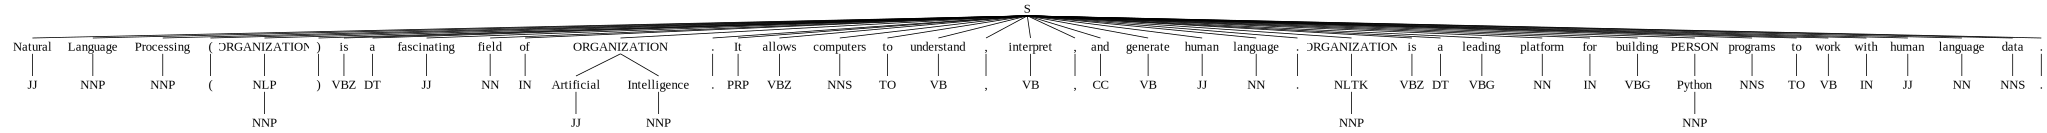

In [37]:
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

from nltk.chunk import ne_chunk

ne_chunk(pos_tags)

## Frequency Distribution

Find most common words

In [82]:
from nltk.probability import FreqDist

freq = FreqDist([w.lower() for w in filtered_words if w.isalpha()])
freq.most_common(10)

[('language', 3),
 ('human', 2),
 ('natural', 1),
 ('processing', 1),
 ('nlp', 1),
 ('fascinating', 1),
 ('field', 1),
 ('artificial', 1),
 ('intelligence', 1),
 ('allows', 1)]

In [83]:
l_freq = FreqDist([w.lower() for w in l_filtered_words if w.isalpha()])
l_freq.most_common(10)

[('text', 4),
 ('data', 4),
 ('ai', 3),
 ('language', 3),
 ('processing', 2),
 ('nlp', 2),
 ('field', 2),
 ('like', 2),
 ('models', 2),
 ('many', 2)]

## N-grams

**N-grams** are sequences of *N* consecutive words (e.g., bigrams = 2 words, trigrams = 3).

They capture common word patterns and phrases, forming the basis for text similarity, language models, and TF-IDF features.


In [91]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

tokens = word_tokenize(long_text.lower())

bigrams = list(ngrams(tokens, 2))
trigrams = list(ngrams(tokens, 3))

bigrams[:10], trigrams[:5]

([("''", 'the'),
  ('the', 'rapid'),
  ('rapid', 'advancement'),
  ('advancement', 'of'),
  ('of', 'artificial'),
  ('artificial', 'intelligence'),
  ('intelligence', '('),
  ('(', 'ai'),
  ('ai', ')'),
  (')', 'has')],
 [("''", 'the', 'rapid'),
  ('the', 'rapid', 'advancement'),
  ('rapid', 'advancement', 'of'),
  ('advancement', 'of', 'artificial'),
  ('of', 'artificial', 'intelligence')])

## Collocations (find meaningful word pairs)

**Collocations** are word combinations that occur together more often than by chance (e.g., “machine learning”).

They help identify meaningful phrases instead of random word pairs.


In [92]:
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

finder = BigramCollocationFinder.from_words(tokens)
finder.nbest(BigramAssocMeasures.likelihood_ratio, 10)

[('the', 'field'),
 ('%', 'accuracy'),
 ('95', '%'),
 ('<', 'div'),
 ('accuracy', 'rate'),
 ('agree', 'that'),
 ('allows', 'computers'),
 ('analysis', 'tasks'),
 ('analyze', 'complex'),
 ('are', 'still')]

## WordNet - synonyms, antonyms, hypernyms

**WordNet** is a lexical database that groups words into sets of synonyms and links them by meaning (antonyms, broader terms, etc.).

It enables basic semantic understanding beyond simple word matching.


In [ ]:
from nltk.corpus import wordnet as wn

syn = wn.synsets("language")[0]

syn.definition(), syn.examples()

('a systematic means of communicating by the use of sounds or conventional symbols',
 ['he taught foreign languages',
  'the language introduced is standard throughout the text',
  'the speed with which a program can be executed depends on the language in which it is written'])

Synonyms / antonyms:

In [71]:
syns = wn.synsets("freeze")

lemmas = []
antonyms = []

for syn in syns:
    curr_lemmas = syn.lemmas()
    lemmas.extend([s.name() for s in curr_lemmas])
    
    for l in curr_lemmas:
        if l.antonyms():
            antonyms.append(l.antonyms()[0].name())

set(antonyms), set(lemmas)

({'boil', 'unblock', 'unfreeze'},
 {'block',
  'freeze',
  'freeze_down',
  'freeze_out',
  'freezing',
  'frost',
  'halt',
  'immobilise',
  'immobilize',
  'stop_dead',
  'suspend'})

## Lemmatization with POS

**Lemmatization with POS** improves basic lemmatization by telling the lemmatizer the grammatical role of each word (noun, verb, adjective, adverb).

NLTK’s WordNet lemmatizer needs POS information to choose the correct base form (lemma). Without it, it often assumes everything is a noun.

In [50]:
from nltk.corpus import wordnet

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

lemmatized = [
    lemmatizer.lemmatize(word, get_wordnet_pos(tag))
    for word, tag in pos_tags
]
'|'.join(lemmatized)

'Natural|Language|Processing|(|NLP|)|be|a|fascinating|field|of|Artificial|Intelligence|.|It|allow|computer|to|understand|,|interpret|,|and|generate|human|language|.|NLTK|be|a|lead|platform|for|build|Python|program|to|work|with|human|language|data|.'

## Chunking (shallow parsing)

Group words into noun phrases

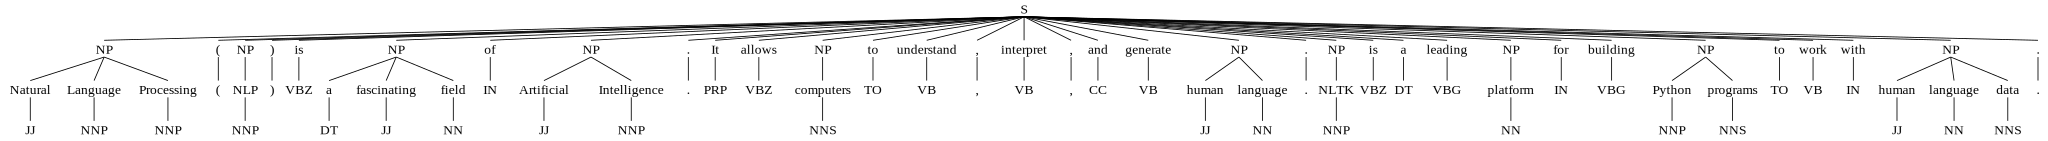

In [51]:
grammar = "NP: {<DT>?<JJ>*<NN.*>+}"

cp = nltk.RegexpParser(grammar)
tree = cp.parse(pos_tags)
tree

## Text similarity (Jaccard)

**Jaccard similarity** is a simple way to measure how similar two texts are by comparing their **shared words**.

It is defined as:

> similarity = (intersection of words) / (union of words)

So it checks how many words overlap between two texts compared to all unique words combined.

---

**Key idea**

* 0 → no overlap at all
* 1 → identical texts
* between 0 and 1 → partial similarity

---

**Why it’s useful**

Jaccard similarity is a **fast baseline method** for:

* comparing short texts
* detecting duplicates
* measuring lexical overlap
* simple clustering of documents

It does not understand meaning — only **word overlap**.


In [52]:
def jaccard_similarity(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)

s1 = word_tokenize("NLP is fun and useful")
s2 = word_tokenize("NLP is very useful and interesting")

jaccard_similarity(s1, s2)

0.5714285714285714

In [72]:
s1 = word_tokenize("It's raining today, take an umbrella")
s2 = word_tokenize("The weather in Paris is going to be very cloudy tomorrow")

jaccard_similarity(s1, s2)

0.0

## TF-IDF with NLTK tokens + scikit-learn

**TF-IDF (Term Frequency–Inverse Document Frequency)** is a way to convert text into numbers that reflect how important a word is in a document compared to a collection of documents.

It combines:

* **TF (Term Frequency)** → how often a word appears in a document
* **IDF (Inverse Document Frequency)** → how rare the word is across all documents

---

**Key idea**

TF-IDF helps you understand:

* which words are **important in a document**
* which words are **common vs unique across documents**
* how to turn text into **ML-ready numerical features**

> It is one of the most important bridges between **text and machine learning models**.


In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = sentences

vectorizer = TfidfVectorizer(tokenizer=word_tokenize, stop_words='english')
X = vectorizer.fit_transform(corpus)

vectorizer.get_feature_names_out()[:20]

array(['(', ')', ',', '.', 'allows', 'artificial', 'building',
       'computers', 'data', 'fascinating', 'field', 'generate', 'human',
       'intelligence', 'interpret', 'language', 'leading', 'natural',
       'nlp', 'nltk'], dtype=object)

In [57]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 31 stored elements and shape (3, 26)>